In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import glob
# --- PATH SETUP ---
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# --- LOCAL IMPORTS ---
%load_ext autoreload
%autoreload 2
from src.analysis import processing as proc
from src.analysis import plotting as viz
from src.analysis import metrics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# --- LOAD ONE CLUSTER PER MODEL/SIZE ---
samples = {}
models = [
    'Lattice',
    'OffLattice',
    'Hybrid'
        ] 
sizes = [
    '1M',
    '10M'
    ]

print(f"Searching for data in: {os.path.join(project_root, 'results', 'analysis_clusters')}")

for model in models:
    for size in sizes:
        base_dir = os.path.join(project_root, 'results', 'analysis_clusters', model, size)
        search_pattern = os.path.join(base_dir, "*.npz")
        
        # finds all files matching the pattern
        files = glob.glob(search_pattern)
        
        if len(files) > 0:
            # picks the first file found (random seed)
            target_file = files[0]
            try:
                coords = proc.load_cluster(target_file)
                samples[f"{model}_{size}"] = coords
                print(f"✅ Loaded {model}_{size}: {coords.shape} (File: {os.path.basename(target_file)})")
                
            except Exception as e:
                print(f" Error loading {model}_{size}: {e}")
        else:
            print(f" No files found for {model}/{size}")

Searching for data in: /Users/ramsaydavis/dla/results/analysis_clusters
✅ Loaded Lattice_1M: (1000000, 2) (File: 77.npz)
✅ Loaded Lattice_10M: (10000000, 2) (File: 10043.npz)
✅ Loaded OffLattice_1M: (1000001, 2) (File: 1409.npz)
✅ Loaded OffLattice_10M: (10000001, 2) (File: 10137.npz)
✅ Loaded Hybrid_1M: (1000001, 2) (File: 2672.npz)
✅ Loaded Hybrid_10M: (10000001, 2) (File: 10241.npz)


In [ ]:
def calculate_sector_evolution(coords, t, num_sectors=360, checkpoints=None):
    """
    Calculate Radius of Gyration (RMS distance from Seed) per angular sector.
    """
    N_total = len(t)

    # --- 1. Log-Spaced Checkpoints ---
    if checkpoints is None:
        start_log = 3.0  # Start at particle 1000 to avoid small-number noise
        end_log = np.log10(N_total)
        num_points = int(20 * (end_log - start_log)) # 20 pts/decade
        checkpoints = np.unique(np.logspace(start_log, end_log, num=num_points).astype(int))
        checkpoints = checkpoints[checkpoints < N_total]

    # --- 2. Calculate Polar Coordinates ---
    # r_sq is the squared distance from the Seed (0,0)
    r_sq = np.sum(coords**2, axis=1)
    
    # Calculate angles [-pi, pi]
    angles = np.arctan2(coords[:, 1], coords[:, 0])

    # --- 3. Center Bins on Axes (Shift-Bin Strategy) ---
    # We want Bin 0 to be centered exactly on 0 degrees (the Lattice Axis).
    # Bin 0 limits: [-0.5 deg, +0.5 deg]
    # To use fast binning, we shift all angles by +0.5 deg (half a bin).
    
    d_theta = 2 * np.pi / num_sectors
    
    # Modulo 2pi ensures everything is in range [0, 2pi]
    angles_shifted = (angles + (d_theta / 2)) % (2 * np.pi)
    
    # Define edges 0..2pi. 
    # Because we shifted the data, 'digitize' will put particles 
    # centered at 0 deg into Bin 0.
    bin_edges = np.linspace(0, 2 * np.pi, num_sectors + 1)
    
    # Get sector indices (0 to num_sectors-1)
    sector_indices = np.digitize(angles_shifted, bin_edges) - 1
    
    # Handle rare edge case where a value equals exactly 2pi
    sector_indices[sector_indices == num_sectors] = 0

    # --- 4. Sort by Time ---
    # Critical for cumulative calculation.
    # We sort once globally to avoid sorting inside the loop.
    sort_idx = np.argsort(t)
    t_sorted = t[sort_idx]
    r_sq_sorted = r_sq[sort_idx]
    sector_indices_sorted = sector_indices[sort_idx]

    # Initialize Output: [Sectors x Time_Checkpoints]
    rg_history = np.zeros((num_sectors, len(checkpoints)))
    rg_history[:] = np.nan 

    # --- 5. Process Each Sector ---
    for s in range(num_sectors):
        # Extract particles for this sector
        in_sector = (sector_indices_sorted == s)
        
        # If sector is empty, leave as NaNs and continue
        if not np.any(in_sector):
            continue

        t_sec = t_sorted[in_sector]
        r_sq_sec = r_sq_sorted[in_sector]
        
        # Calculate Cumulative RMS Distance (Rg)
        # Rg(t) = sqrt( Sum(r^2) / Count(t) )
        cum_r_sq = np.cumsum(r_sq_sec)
        counts = np.arange(1, len(t_sec) + 1)
        rg_evolution = np.sqrt(cum_r_sq / counts)
        
        # --- 6. Map to Checkpoints (The "Freezing" Logic) ---
        # Find the index of the particle that exists at or before each checkpoint.
        # side='right' ensures we grab the latest possible value.
        idx_map = np.searchsorted(t_sec, checkpoints, side='right') - 1
        
        # If idx_map is -1, the checkpoint is before the first particle arrived (keep NaN).
        # If idx_map is max_index, the checkpoint is after the last particle (keep max value).
        valid_mask = (idx_map >= 0)
        
        if np.any(valid_mask):
            valid_indices = idx_map[valid_mask]
            rg_history[s, valid_mask] = rg_evolution[valid_indices]

    # --- 7. Prepare Return Values ---
    bin_centers = np.linspace(0, 2*np.pi, num_sectors, endpoint=False)
    
    return bin_centers, checkpoints, rg_history

In [11]:
cluster_key = "Lattice_10M"

if cluster_key in samples:
    coords_real = samples[cluster_key]
    N_total = len(coords_real)
    
    # 2. Generate the time array (assuming particles are in arrival order)
    t_real = np.arange(1, N_total + 1)
    
    print(f"Processing {cluster_key} with {N_total} particles...")
    
    # 3. Run the sector evolution function
    bin_centers, checkpoints, rg_history = calculate_sector_evolution(
        coords_real, 
        t_real, 
        num_sectors=360
    )
    print("Processing complete!")

    

Processing Lattice_10M with 10000000 particles...
Processing complete!


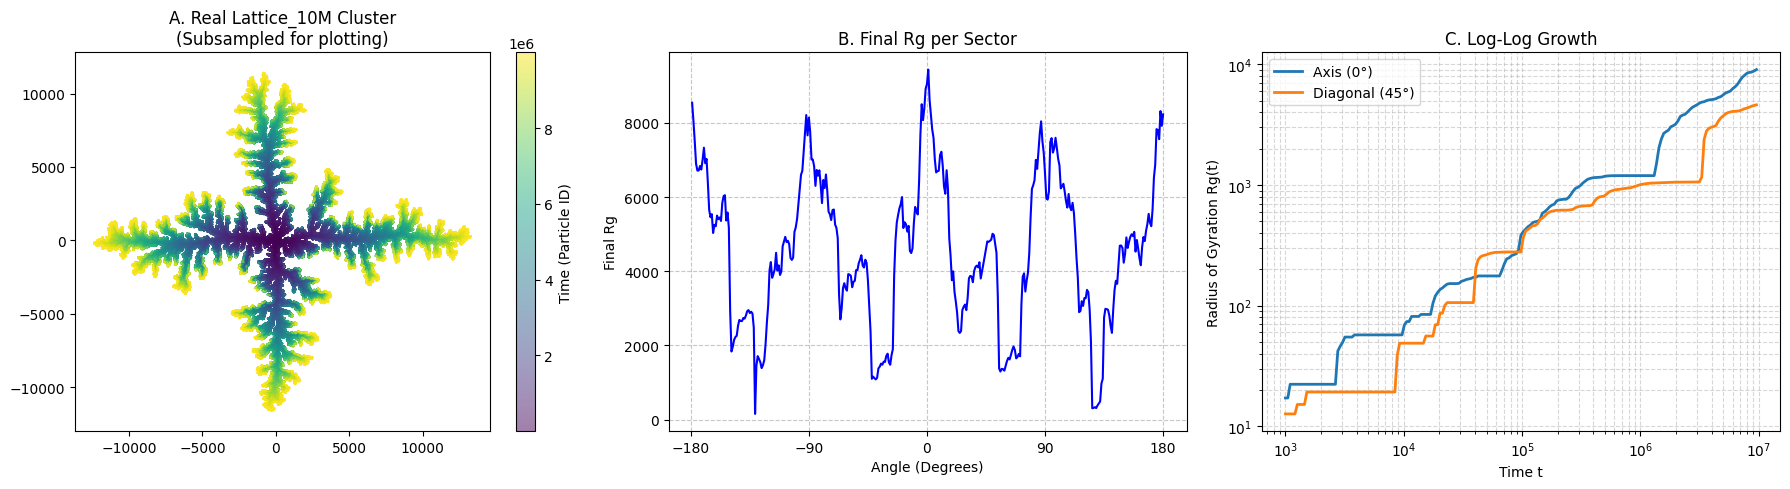

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

"""# --- Plot A: The Real Cluster ---
# Note: Plotting 1M points can be slow, so we plot every 10th point (::10) just for speed
step = 10 
sc = axes[0].scatter(coords_real[::step, 0], coords_real[::step, 1], 
                        c=t_real[::step], cmap='viridis', s=0.1, alpha=0.5)
axes[0].set_title(f"A. Real {cluster_key} Cluster\n(Subsampled for plotting)")
axes[0].axis('equal')
plt.colorbar(sc, ax=axes[0], label='Time (Particle ID)')"""

# --- Plot B: Final Rg vs Angle ---
axes[1].plot(np.degrees(bin_centers), rg_history[:, -1], color='blue')
axes[1].set_title("Final Rg per Sector")
axes[1].set_xlabel("Angle (Degrees)")
axes[1].set_ylabel("Final Rg")
axes[1].set_xticks([-180, -90, 0, 90, 180])
axes[1].grid(True, linestyle='--', alpha=0.7)

# --- Plot C: Log-Log Growth ---
# Extract the Axis (0 deg) and Diagonal (45 deg)
idx_axis = np.argmin(np.abs(bin_centers - 0.0))
idx_diag = np.argmin(np.abs(bin_centers - np.deg2rad(45.0)))

axes[2].loglog(checkpoints, rg_history[idx_axis, :], label='Axis (0°)', linewidth=2)
axes[2].loglog(checkpoints, rg_history[idx_diag, :], label='Diagonal (45°)', linewidth=2)
axes[2].set_title("Log-Log Growth")
axes[2].set_xlabel("Time t")
axes[2].set_ylabel("Radius of Gyration Rg(t)")
axes[2].legend()
axes[2].grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



In [13]:
# 1. Define our edge-case test angles (in degrees)
test_angles_deg = [
    0.0,    # Exactly on the axis (Should be Bin 0)
    0.4,    # Just above the axis (Should be Bin 0)
    0.6,    # Pushed into the next bin (Should be Bin 1)
    180.0,  # The opposite axis (Should be Bin 180)
    359.4,  # Just below the wrap-around (Should be Bin 359)
    359.6,  # Pushed across the wrap-around (Should be Bin 0)
    -0.4,   # Negative angle equivalent to 359.6 (Should be Bin 0)
]

# Convert to radians mapped to [-pi, pi] exactly how np.arctan2 works
angles_rad = np.deg2rad(test_angles_deg)
angles_rad = np.arctan2(np.sin(angles_rad), np.cos(angles_rad))

# 2. Run the exact binning logic from the function
num_sectors = 360
d_theta = 2 * np.pi / num_sectors

# Shift and wrap
angles_shifted = (angles_rad + (d_theta / 2)) % (2 * np.pi)
bin_edges = np.linspace(0, 2 * np.pi, num_sectors + 1)

# Digitize
sector_indices = np.digitize(angles_shifted, bin_edges) - 1
sector_indices[sector_indices == num_sectors] = 0 # Handle 2pi edge case

# 3. Print the results clearly
print(f"{'Input Angle':<15} | {'Shifted (Deg)':<15} | {'Resulting Bin'}")
print("-" * 50)
for orig, shifted, bin_idx in zip(test_angles_deg, np.rad2deg(angles_shifted), sector_indices):
    print(f"{orig:>11.1f}°   | {shifted:>13.1f}°   | Bin {bin_idx}")

Input Angle     | Shifted (Deg)   | Resulting Bin
--------------------------------------------------
        0.0°   |           0.5°   | Bin 0
        0.4°   |           0.9°   | Bin 0
        0.6°   |           1.1°   | Bin 1
      180.0°   |         180.5°   | Bin 180
      359.4°   |         359.9°   | Bin 359
      359.6°   |           0.1°   | Bin 0
       -0.4°   |           0.1°   | Bin 0
